In [1]:
import math
import time
import numpy as np
import torch
from d2l import torch as d2l
torch.cuda.is_available(), torch.__version__

(True, '2.9.1+cu128')

In [2]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [3]:
class Timer:
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        self.tik = time.time()
    def stop(self):
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        return sum(self.times) / len(self.times)
    def sum(self):
        return sum(self.times)
    def cumsum(self):
        return np.array(self.times).cumsum().tolist()

In [4]:
c = torch.zeros([n])
timer = Timer()
for i in range(n):
    c[i]  = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.04371 sec'

In [5]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00017 sec'

In [6]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma **2)
    return p * np.exp(-.5/sigma**2 * (x - mu)**2)

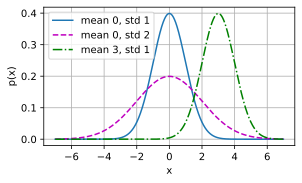

In [7]:
x = np.arange(-7, 7, .01)
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(
    x, 
    [normal(x, mu, sigma) for mu, sigma in params], 
    xlabel='x', 
    ylabel='p(x)', 
    figsize=(4.5, 2.5),
    legend = [f'mean {mu}, std {sigma}' for mu, sigma in params]
)

In [8]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [9]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
f"features: {features[0]}, \nlabel: {labels[0]}"

'features: tensor([ 0.2164, -0.4726]), \nlabel: tensor([6.2430])'

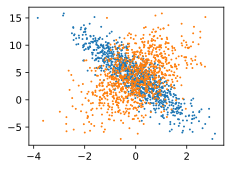

In [10]:
d2l.set_figsize()
d2l.plt.scatter(features[:,(1)].detach().numpy(), labels.detach().numpy(), 1)
d2l.plt.scatter(features[:,(0)].detach().numpy(), labels.detach().numpy(), 1)

In [11]:
import random
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i+batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [12]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, y)
    break

tensor([[-1.2641, -1.3406],
        [-0.6914,  1.4661],
        [ 0.6800,  0.5597],
        [ 0.7658,  0.0697],
        [-0.2592, -0.1762],
        [-1.4907, -1.3316],
        [ 2.0243,  0.5473],
        [ 1.0840, -0.4008],
        [ 1.7993, -1.8051],
        [-0.7857, -1.2284]]) tensor([[ 6.2374],
        [-2.1543],
        [ 3.6688],
        [ 5.5095],
        [ 4.2634],
        [ 5.7540],
        [ 6.3895],
        [ 7.7297],
        [13.9356],
        [ 6.7997]])


In [13]:
w = torch.normal(0, .01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [14]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

In [15]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2/2

In [16]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [17]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [18]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.036847
epoch 2, loss 0.000141
epoch 3, loss 0.000052


In [19]:
true_w - w.reshape(true_w.shape), true_b - b

(tensor([ 0.0008, -0.0001], grad_fn=<SubBackward0>),
 tensor([0.0003], grad_fn=<RsubBackward1>))

In [20]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [21]:
def load_array(data_arrays, batch_size, is_train=True):
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [22]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)
next(iter(data_iter))

[tensor([[-0.0324, -0.1488],
         [-1.6174,  1.1840],
         [ 0.1470, -1.2449],
         [-0.0523, -1.9573],
         [-1.0763, -1.1229],
         [ 0.7652, -0.7556],
         [-0.5063,  1.4042],
         [-1.2942, -0.1767],
         [ 0.4544, -0.6297],
         [-0.0463,  0.7180]]),
 tensor([[ 4.6226],
         [-3.0560],
         [ 8.7362],
         [10.7592],
         [ 5.8739],
         [ 8.2882],
         [-1.5692],
         [ 2.2055],
         [ 7.2543],
         [ 1.6496]])]

In [23]:
net = torch.nn.Sequential(torch.nn.Linear(2, 1))

In [24]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [25]:
loss = torch.nn.MSELoss()

In [26]:
trainer = torch.optim.SGD(net.parameters(), lr=.03)

In [27]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        print(net[0].weight.grad, net[0].bias.grad)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        # trainer.zero_grad()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

None None
tensor([[-1.8540,  1.4901]]) tensor([-5.4911])
tensor([[-3.6191,  8.7580]]) tensor([-7.9466])
tensor([[-4.1521,  8.9640]]) tensor([-7.3587])
tensor([[-3.5119,  1.5768]]) tensor([-7.3996])
tensor([[-3.8060,  2.7269]]) tensor([-6.5045])
tensor([[-5.8262,  1.8309]]) tensor([-5.1955])
tensor([[-8.0464,  6.8701]]) tensor([-5.8122])
tensor([[-2.6472,  4.7397]]) tensor([-5.2294])
tensor([[-1.3303,  6.5424]]) tensor([-3.6525])
tensor([[0.3598, 3.3339]]) tensor([-5.6635])
tensor([[-2.0987,  2.1030]]) tensor([-5.4663])
tensor([[-3.3465,  4.1793]]) tensor([-4.1287])
tensor([[-0.6780,  3.7962]]) tensor([-4.7077])
tensor([[-1.4454,  1.7717]]) tensor([-3.0741])
tensor([[-0.0892,  2.4678]]) tensor([-4.4957])
tensor([[-0.4486,  2.4267]]) tensor([-4.1550])
tensor([[-0.8955,  2.2158]]) tensor([-2.9146])
tensor([[-0.3355,  3.7864]]) tensor([-3.3829])
tensor([[0.5437, 3.2239]]) tensor([-2.1340])
tensor([[-2.3504,  3.1407]]) tensor([-2.1482])
tensor([[-1.2469,  2.7874]]) tensor([-3.0739])
tensor(

In [28]:
true_w - net[0].weight.data.reshape(true_w.shape), true_b - net[0].bias.data

(tensor([ 0.0003, -0.0002]), tensor([0.0001]))

In [29]:
from IPython import display
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

In [30]:
num_inputs = 784
num_outputs = 10
W = torch.normal(0, 0.1, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

In [31]:
X = torch.tensor([[1.,2.,3.],[4.,5.,6.]])
X.sum(0, keepdim=True), X.sum(1, keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [32]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)
    return X_exp / partition

In [33]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

In [34]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[.1,.3,.6],[.3,.2,.5]])
y_hat[[0,1], y]

tensor([0.1000, 0.5000])

In [35]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])
cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [36]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())
accuracy(y_hat, y) / len(y)

0.5

In [37]:
def evaluate_accuracy(net, data_iter):
    if isinstance(net, torch.nn.Module):
        net.eval()
    metric = A